In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



iris = sns.load_dataset('iris')
iris.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
from sklearn.datasets import load_iris
iris_data = load_iris()
type(iris_data)
iris_data.keys()


dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [5]:
iris_df = pd.DataFrame(data=iris_data['data'], columns=iris_data['feature_names'])
iris_df['Iris type'] = iris_data['target']
iris_df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Iris type
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [7]:
print(f"Dataset shape: {iris.shape}")
iris.info()
iris.describe()


Dataset shape: (150, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [8]:
iris.isnull().sum()


sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [10]:
import seaborn as sns
import pandas as pd


df = sns.load_dataset("iris")

# Now df exists, so you can c
dup = df.duplicated().sum()
print(f"Number of duplicated rows: {dup}")


Number of duplicated rows: 1


In [15]:
print(iris_df['Iris type'].value_counts())


Iris type
0    50
1    50
2    50
Name: count, dtype: int64


In [16]:

print("Encoded Species Values:", iris_df['Iris type'].unique())


Encoded Species Values: [0 1 2]


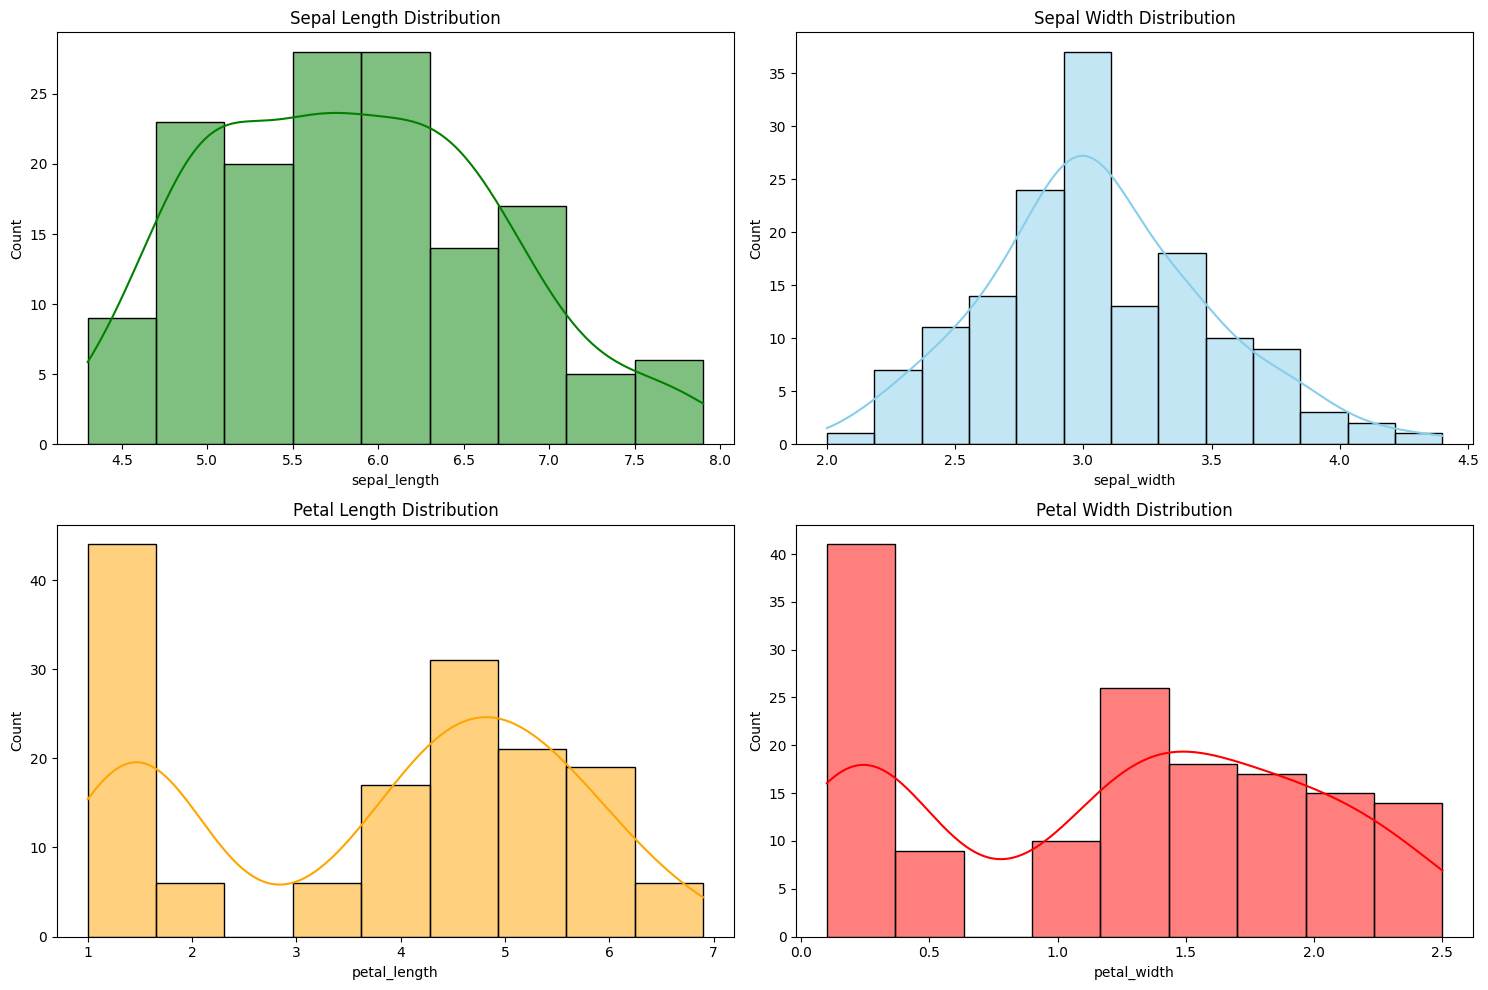

In [17]:
ig, axes = plt.subplots(2, 2, figsize=(15, 10))
sns.histplot(iris['sepal_length'], kde=True, ax=axes[0, 0], color='green')
axes[0, 0].set_title('Sepal Length Distribution')

sns.histplot(iris['sepal_width'], kde=True, ax=axes[0, 1], color='skyblue')
axes[0, 1].set_title('Sepal Width Distribution')

sns.histplot(iris['petal_length'], kde=True, ax=axes[1, 0], color='orange')
axes[1, 0].set_title('Petal Length Distribution')

sns.histplot(iris['petal_width'], kde=True, ax=axes[1, 1], color='red')
axes[1, 1].set_title('Petal Width Distribution')

plt.tight_layout()
plt.show()

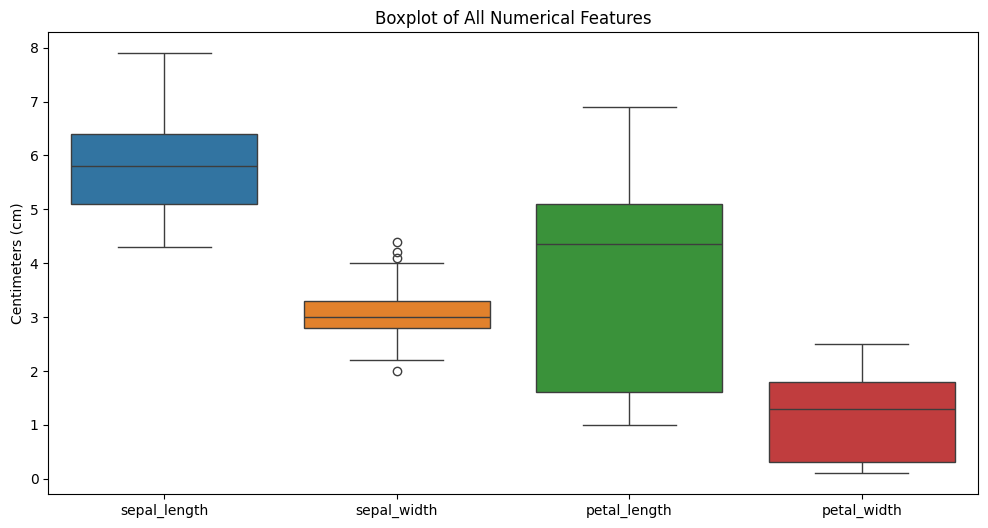

In [18]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=iris.drop('species', axis=1))
plt.title('Boxplot of All Numerical Features')
plt.ylabel('Centimeters (cm)')
plt.show()

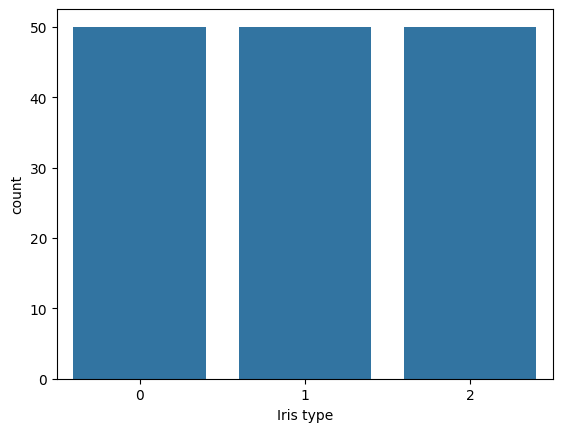

In [20]:
sns.countplot(x='Iris type', data=iris_df)
plt.show()


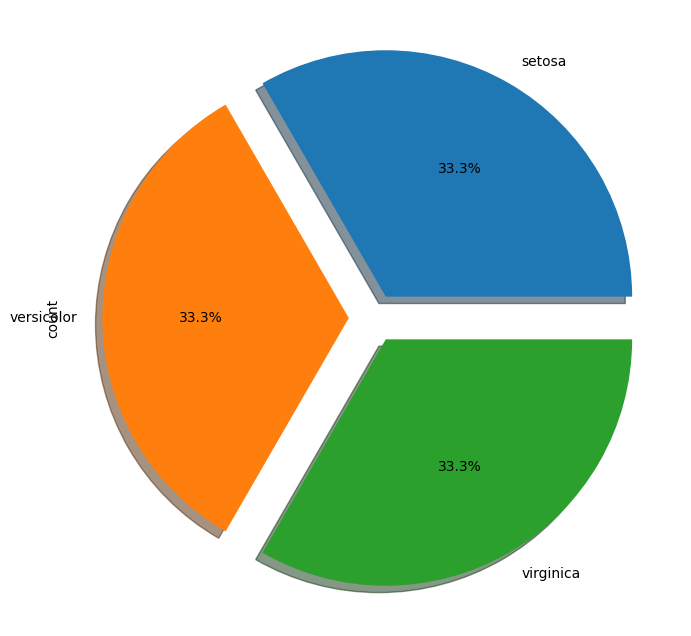

In [22]:
iris['species'].value_counts().plot.pie(
    explode=[0.1,0.1,0.1],
    autopct='%1.1f%%',
    shadow=True,
    figsize=(10,8)
)
plt.show()


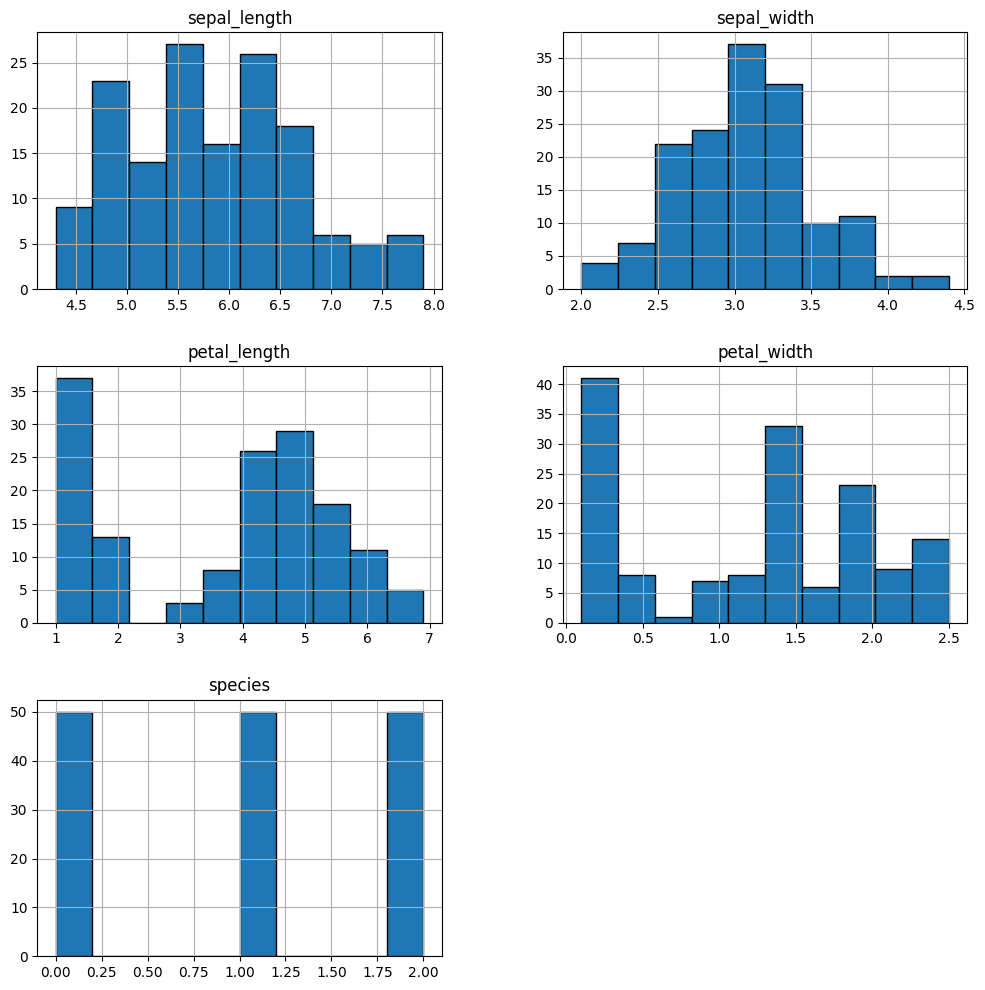

In [23]:
df.hist(edgecolor='black', figsize=(12,12))
plt.show()

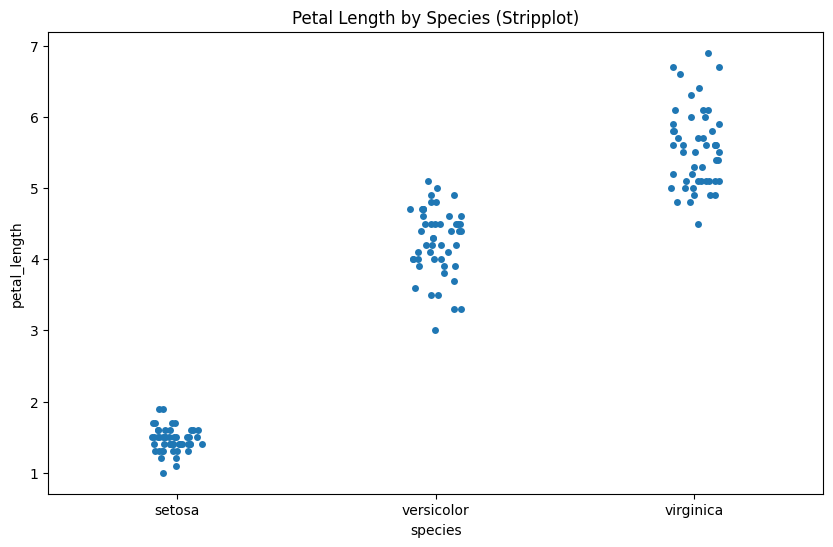

In [37]:
plt.figure(figsize=(10, 6))
sns.stripplot(
    x="species", 
    y="petal_length", 
    data=iris, 
    jitter=True, 
    edgecolor="auto"   
)
plt.title("Petal Length by Species (Stripplot)")
plt.show()


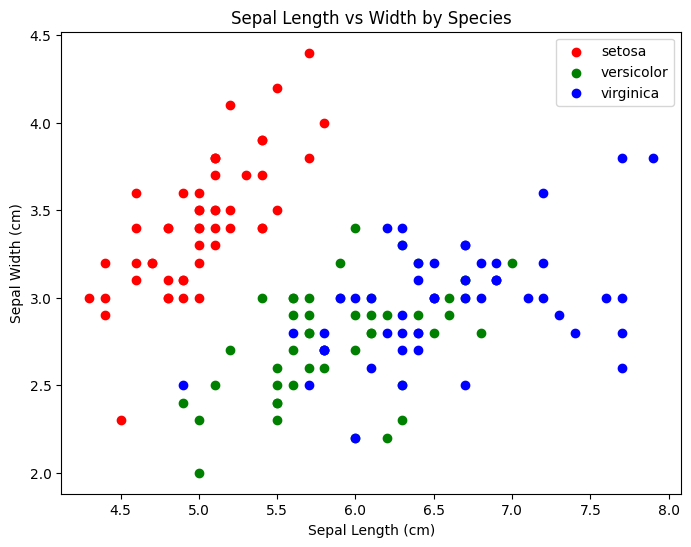

In [27]:
species = iris['species'].unique()
colors = ['red', 'green', 'blue']

plt.figure(figsize=(8, 6))
for i, sp in enumerate(species):
    subset = iris[iris['species'] == sp]
    plt.scatter(subset['sepal_length'], subset['sepal_width'], c=colors[i], label=sp)
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Sepal Length vs Width by Species')
plt.legend()
plt.show()


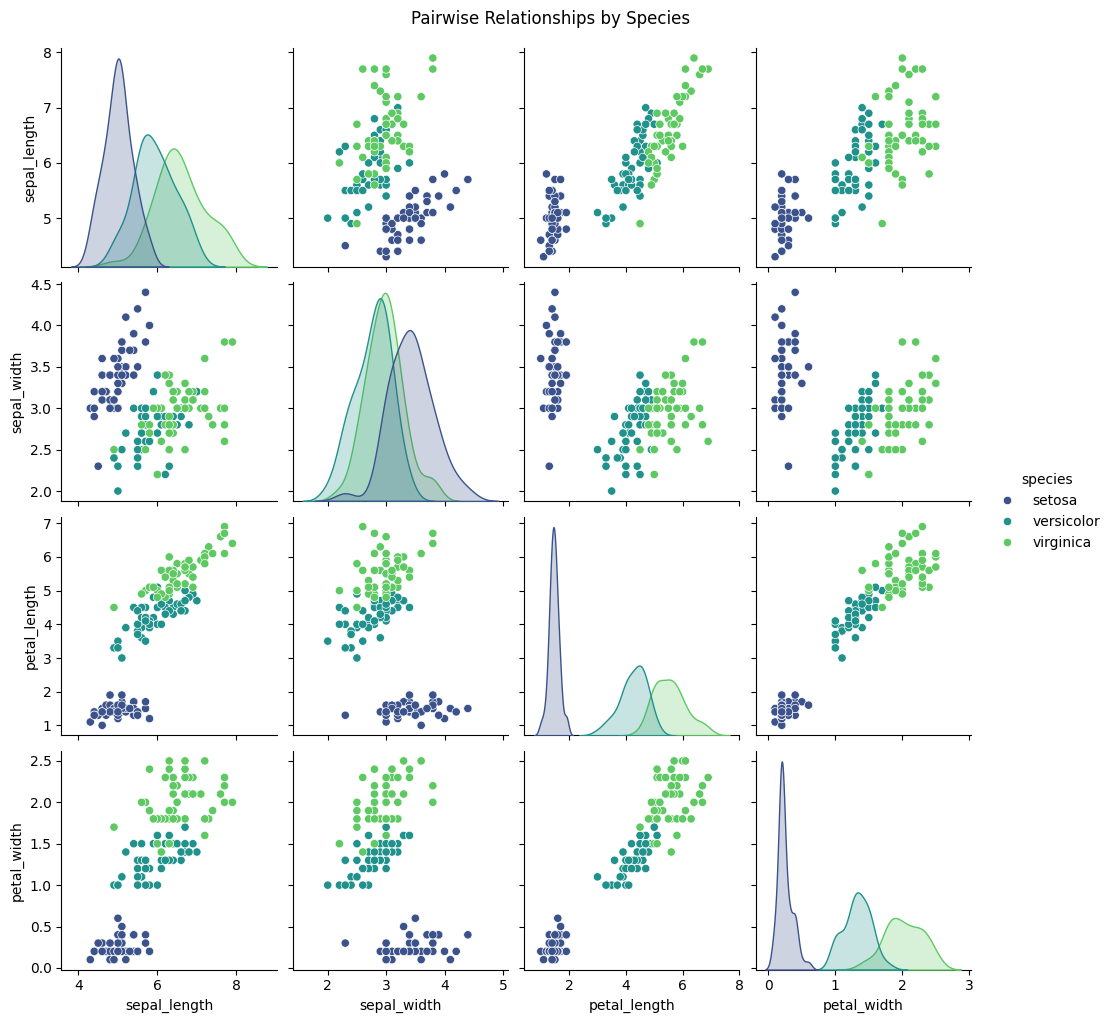

In [29]:
sns.pairplot(iris, hue='species', palette='viridis', height=2.5)
plt.suptitle('Pairwise Relationships by Species', y=1.02)
plt.show()


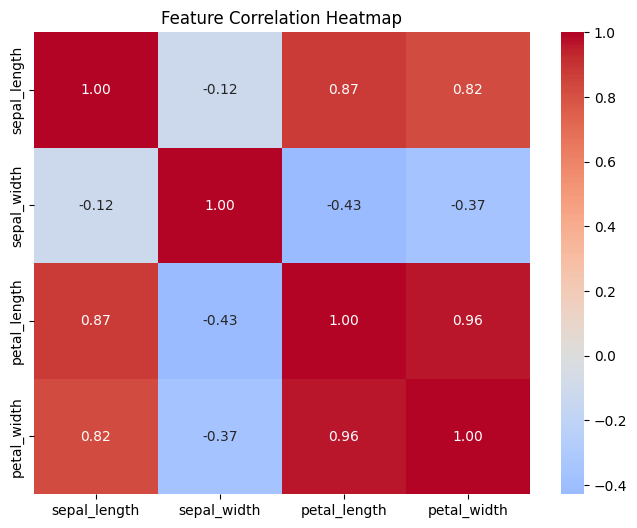

In [30]:
corr = iris.drop('species', axis=1).corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

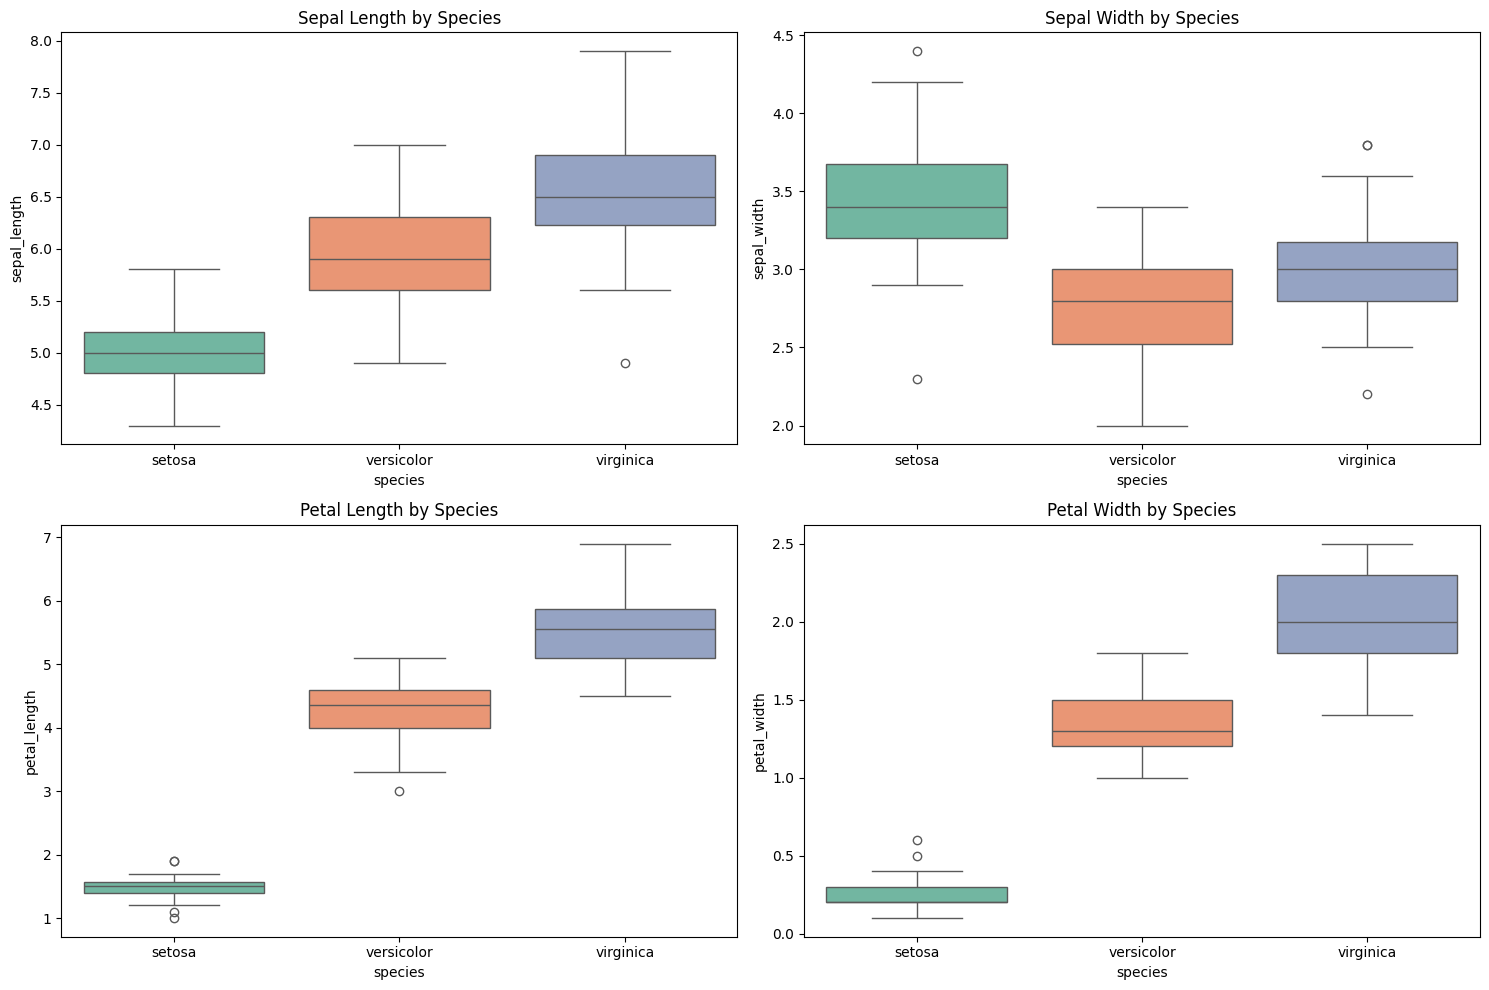

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.boxplot(x='species', y='sepal_length', hue='species', data=iris,
            ax=axes[0, 0], palette='Set2', legend=False)
axes[0, 0].set_title('Sepal Length by Species')

sns.boxplot(x='species', y='sepal_width', hue='species', data=iris,
            ax=axes[0, 1], palette='Set2', legend=False)
axes[0, 1].set_title('Sepal Width by Species')

sns.boxplot(x='species', y='petal_length', hue='species', data=iris,
            ax=axes[1, 0], palette='Set2', legend=False)
axes[1, 0].set_title('Petal Length by Species')

sns.boxplot(x='species', y='petal_width', hue='species', data=iris,
            ax=axes[1, 1], palette='Set2', legend=False)
axes[1, 1].set_title('Petal Width by Species')

plt.tight_layout()
plt.show()


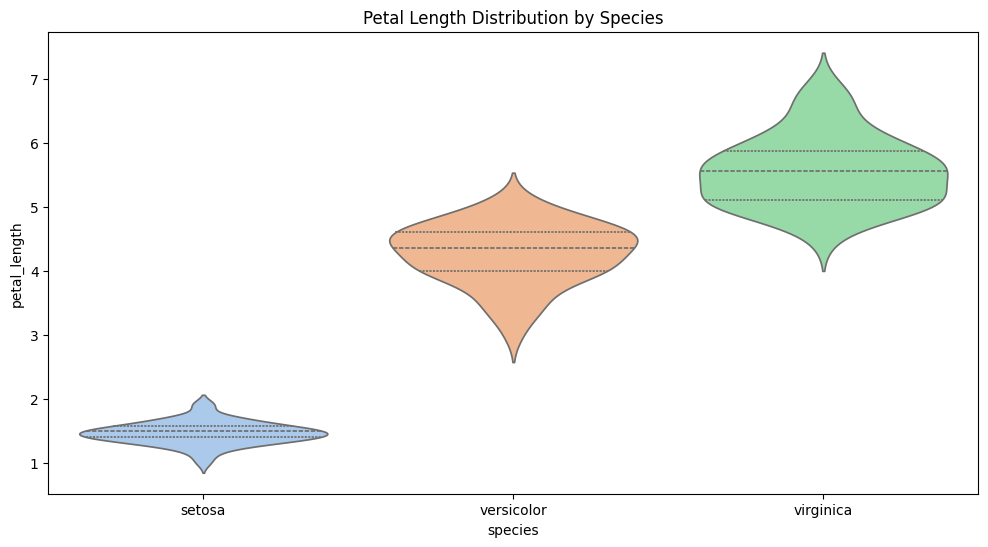

In [36]:
plt.figure(figsize=(12, 6))
sns.violinplot(
    x='species', 
    y='petal_length', 
    hue='species',         
    data=iris, 
    inner='quartile', 
    palette='pastel', 
    legend=False            
)
plt.title('Petal Length Distribution by Species')
plt.show()


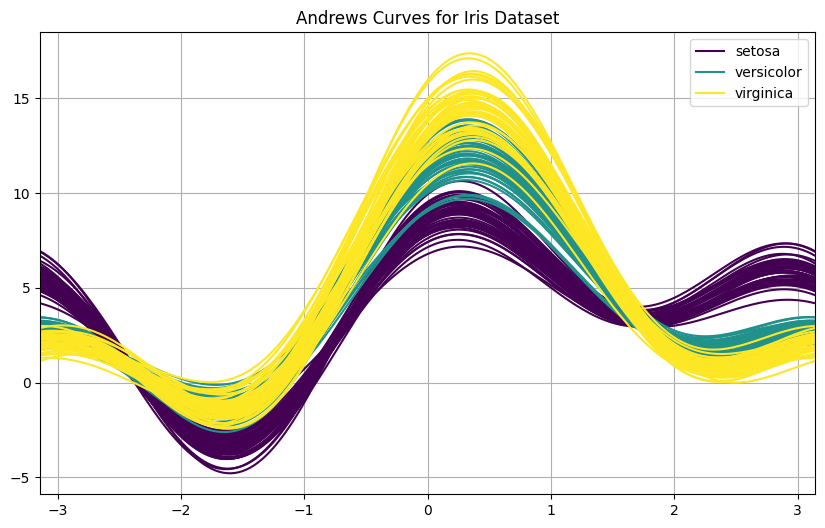

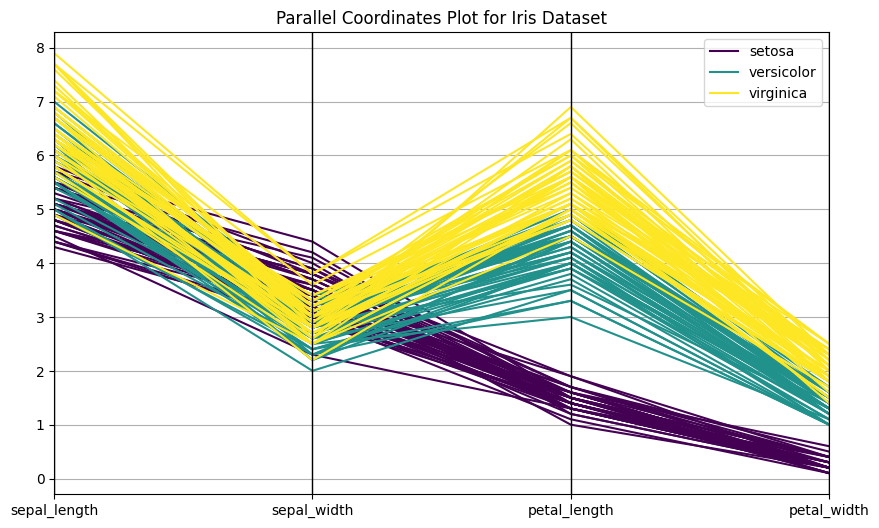

In [35]:
from pandas.plotting import andrews_curves, parallel_coordinates
plt.figure(figsize=(10, 6))
andrews_curves(iris, 'species', colormap='viridis')
plt.title('Andrews Curves for Iris Dataset')
plt.show()

plt.figure(figsize=(10, 6))
parallel_coordinates(iris, 'species', colormap='viridis')
plt.title('Parallel Coordinates Plot for Iris Dataset')
plt.show()
